# TABELAS E CÓDIGOS DO EXPERIMENTO DA CARGA/MASSA DO ELÉTRON

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Experimento sem campo elétrico:

In [3]:
Voltagem1 = np.array([1.2,  1.8,  3,    3,    4.2,  4.8,  5.4,  5.4,  6,    6.6])
sigV1 = 0.3 # Volts
Amperagem = np.array([0.12, 0.15, 0.21, 0.26, 0.32, 0.36, 0.40, 0.42, 0.45, 0.51])
sigA = 0.008 * Amperagem # Amperes
Quadrados = np.array([7,    9,    14,   16,   20,   22,   24,   25,   27,   30])
Quadrados = Quadrados * 2 # Convertendo para milímetros
sigM = 1 # Milímetros

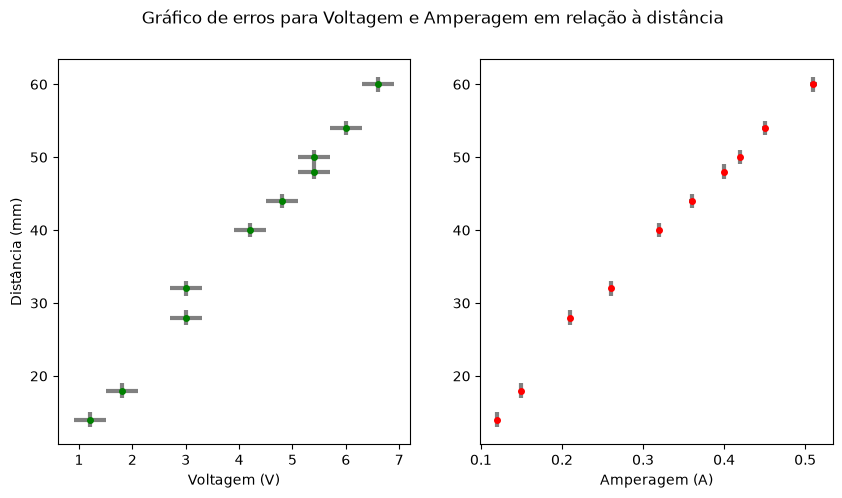

In [4]:
fig, ax1 = plt.subplots(1,2, figsize=(10, 5))

ax1[0].errorbar(Voltagem1, Quadrados, xerr=sigV1, yerr=sigM, fmt='o', markersize=4, color='green', ecolor='gray', elinewidth=3, capsize=0)
ax1[0].set_xlabel('Voltagem (V)')
ax1[0].set_ylabel('Distância (mm)')

ax1[1].errorbar(Amperagem, Quadrados, xerr=sigA, yerr=sigM, fmt='o', markersize=4, color='red', ecolor='gray', elinewidth=3, capsize=0)
ax1[1].set_xlabel('Amperagem (A)')
fig.suptitle('Gráfico de erros para Voltagem e Amperagem em relação à distância')
plt.show()


In [5]:
# Ajuste linear por minimos quadrados: y = a*x + b
coef_v = np.polyfit(Voltagem1, Quadrados, 1)
coef_i = np.polyfit(Amperagem, Quadrados, 1, w=1/sigA)  # Ajuste ponderado para Amperagem

reta_v = np.polyval(coef_v, Voltagem1)
reta_i = np.polyval(coef_i, Amperagem)

print(f'Voltagem: y = {coef_v[0]:.4f}x + {coef_v[1]:.4f}')
print(f'Amperagem: y = {coef_i[0]:.4f}x + {coef_i[1]:.4f}')

Voltagem: y = 8.4198x + 3.9421
Amperagem: y = 121.9918x + -0.0758


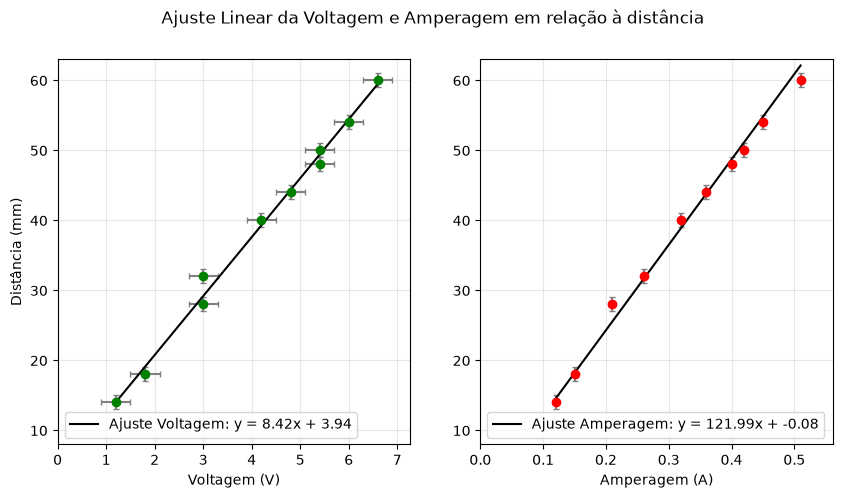

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].errorbar(Voltagem1, Quadrados, xerr=sigV1, yerr=sigM, fmt='o', color='green', ecolor='gray', capsize=2)
ax[0].plot(Voltagem1, reta_v, color='black', label=f'Ajuste Voltagem: y = {coef_v[0]:.2f}x + {coef_v[1]:.2f}')
ax[0].set_xlabel('Voltagem (V)')
ax[0].set_ylabel('Distância (mm)')
ax[0].grid(alpha=0.3)
ax[0].set_xlim(0, max(Voltagem1)*1.1)
ax[0].set_ylim(8,63)
ax[0].legend()

ax[1].errorbar(Amperagem, Quadrados, xerr=sigA, yerr=sigM, fmt='o', color='red', ecolor='gray', capsize=2)
ax[1].plot(Amperagem, reta_i, color='black', label=f'Ajuste Amperagem: y = {coef_i[0]:.2f}x + {coef_i[1]:.2f}')
ax[1].set_xlabel('Amperagem (A)')
ax[1].grid(alpha=0.3)
ax[1].set_xlim(0, max(Amperagem)*1.1)
ax[1].set_ylim(8,63)
ax[1].legend()

fig.suptitle('Ajuste Linear da Voltagem e Amperagem em relação à distância')
plt.show()

Experimento com campo elétrico

In [7]:
Voltagem1 = np.array([1.2,  1.8,  2.4,  3,    3.6,  4.2,  4.8,  5.4,  6])
sigV1 = 0.3 # Volts
Amperagem = np.array([0.12, 0.16, 0.19, 0.22, 0.27, 0.32, 0.37, 0.42, 0.45])
sigA = 0.008 * Amperagem # Amperes
Quadrados = np.array([7,    10,   12,   14,   17,   20,   22,   25,   27])
Quadrados = Quadrados * 2 # Convertendo para milímetros
sigM = 1 # Milímetros
Voltagem2 = np.array([120,  180,  220,  260,   300, 360,  400,  460,  500])
sigV2 = 10 # Volts

In [8]:
# Ajuste linear por minimos quadrados: y = a*x + b
coef_v1 = np.polyfit(Voltagem1, Quadrados, 1)
coef_i = np.polyfit(Amperagem, Quadrados, 1, w=1/sigA)  # Ajuste ponderado para Amperagem
coef_v2 = np.polyfit(Voltagem2, Quadrados, 1)

reta_v1 = np.polyval(coef_v1, Voltagem1)
reta_i = np.polyval(coef_i, Amperagem)
reta_v2 = np.polyval(coef_v2, Voltagem2)


print(f'Voltagem 1: y = {coef_v1[0]:.4f}x + {coef_v1[1]:.4f}')
print(f'Amperagem: y = {coef_i[0]:.4f}x + {coef_i[1]:.4f}')
print(f'Voltagem 2: y = {coef_v2[0]:.4f}x + {coef_v2[1]:.4f}')

Voltagem 1: y = 8.3889x + 4.0222
Amperagem: y = 122.8391x + -0.0364
Voltagem 2: y = 0.1070x + 0.9365


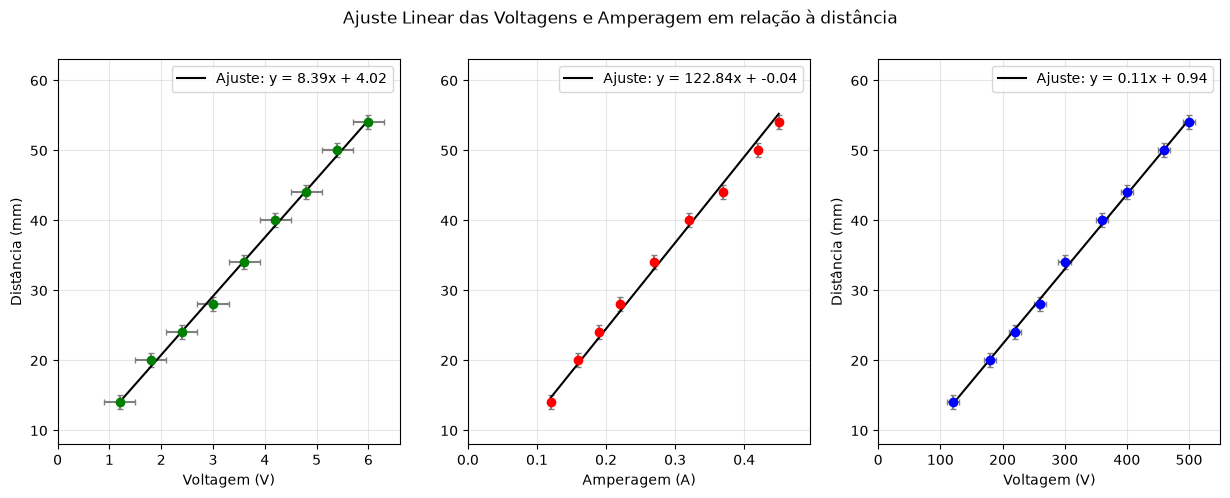

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].errorbar(Voltagem1, Quadrados, xerr=sigV1, yerr=sigM, fmt='o', color='green', ecolor='gray', capsize=2)
ax[0].plot(Voltagem1, reta_v1, color='black', label=f'Ajuste: y = {coef_v1[0]:.2f}x + {coef_v1[1]:.2f}')
ax[0].set_xlabel('Voltagem (V)')
ax[0].set_ylabel('Distância (mm)')
ax[0].grid(alpha=0.3)
ax[0].set_xlim(0, max(Voltagem1)*1.1)
ax[0].set_ylim(8,63)
ax[0].legend()

ax[1].errorbar(Amperagem, Quadrados, xerr=sigA, yerr=sigM, fmt='o', color='red', ecolor='gray', capsize=2)
ax[1].plot(Amperagem, reta_i, color='black', label=f'Ajuste: y = {coef_i[0]:.2f}x + {coef_i[1]:.2f}')
ax[1].set_xlabel('Amperagem (A)')
ax[1].grid(alpha=0.3)
ax[1].set_xlim(0, max(Amperagem)*1.1)
ax[1].set_ylim(8,63)
ax[1].legend()

ax[2].errorbar(Voltagem2, Quadrados, xerr=sigV2, yerr=sigM, fmt='o', color='blue', ecolor='gray', capsize=2)
ax[2].plot(Voltagem2, reta_v2, color='black', label=f'Ajuste: y = {coef_v2[0]:.2f}x + {coef_v2[1]:.2f}')
ax[2].set_xlabel('Voltagem (V)')
ax[2].set_ylabel('Distância (mm)')
ax[2].grid(alpha=0.3)
ax[2].set_xlim(0, max(Voltagem2)*1.1)
ax[2].set_ylim(8,63)
ax[2].legend()

fig.suptitle('Ajuste Linear das Voltagens e Amperagem em relação à distância')
plt.show()

In [10]:
Tensao = [150, 200, 250, 300, 300] # Volts
Raios = np.array([5,4,3,2])
sigR = 0.2 # milímetros
Corrente_150 = [0.96, 1.34, 1.82, 3.12]
sigA = 0.008 * np.array(Corrente_150) # Amperes
Tensao_150 = [4,6,8,15]
sigV = 0.1
Corrente_200 = [1.23, 1.54, 2.12, 3.48]
Tensao_200 = [5,7,10,17]
Corrente_250 = [1.36, 1.74, 2.33, 3.75]
Tensao_250 = [6,8,11,18]
Corrente_300_15 = [1.43, 1.79, 2.42, 3.91]
Tensao_300_15 = [6,8,12,19]
Corrente_300_50 = [1.54, 1.95, 2.64, 3.84]
Tensao_300_50 = [6,9,13,19]
table_I = np.array([Corrente_150, Corrente_200, Corrente_250, Corrente_300_15, Corrente_300_50])
table_V = np.array([Tensao_150, Tensao_200, Tensao_250, Tensao_300_15, Tensao_300_50])
print(table_I.T)
print(table_V.T)
print(Raios)

[[0.96 1.23 1.36 1.43 1.54]
 [1.34 1.54 1.74 1.79 1.95]
 [1.82 2.12 2.33 2.42 2.64]
 [3.12 3.48 3.75 3.91 3.84]]
[[ 4  5  6  6  6]
 [ 6  7  8  8  9]
 [ 8 10 11 12 13]
 [15 17 18 19 19]]
[5 4 3 2]


In [11]:
# 1. Constantes da Montagem (Bobinas de Helmholtz)
N = 130
R = 0.15 # raio em metros
mu_0 = 4 * np.pi * 1e-7
C1 = (4/5)**1.5 * mu_0 * N / R
B_terra = 1.8e-5

# 2. Incertezas Instrumentais
delta_U = 5     # Volts

# 3. Dados Coletados
U = np.array([150, 200, 250, 300, 300]) # Tensões de aceleração

# 4. Cálculo de e/m0 e Propagação de Incerteza
for i,r in enumerate(Raios*0.01):  # Convertendo para metros
    I = np.array(table_I.T[i])  # Correntes correspondentes ao raio r
    sigA = 0.008*I # Amperes
    B = C1 * I + B_terra  # Campo magnético total
    em0 = (2 * U) / ((B**2) * (r**2))

    # Aplicando a fórmula de propagação de erros rigorosa
    erro_relativo = np.sqrt((delta_U / U)**2 + 4*(sigA / I)**2 + 4*(sigR*0.01 / r)**2)
    delta_em0 = em0 * erro_relativo
    
    print(f"Para r = {r} m:")
    for i in range(len(U)):
        print(f"U = {U[i]:3}V | I = {I[i]:.2f}A  ->  e/m0 = {em0[i]*1e-11:.2f}({delta_em0[i]*1e-11:.2f}) x 10^11")
    print()

Para r = 0.05 m:
U = 150V | I = 0.96A  ->  e/m0 = 2.04(0.18) x 10^11
U = 200V | I = 1.23A  ->  e/m0 = 1.68(0.14) x 10^11
U = 250V | I = 1.36A  ->  e/m0 = 1.72(0.14) x 10^11
U = 300V | I = 1.43A  ->  e/m0 = 1.87(0.16) x 10^11
U = 300V | I = 1.54A  ->  e/m0 = 1.62(0.13) x 10^11

Para r = 0.04 m:
U = 150V | I = 1.34A  ->  e/m0 = 1.66(0.18) x 10^11
U = 200V | I = 1.54A  ->  e/m0 = 1.68(0.18) x 10^11
U = 250V | I = 1.74A  ->  e/m0 = 1.66(0.17) x 10^11
U = 300V | I = 1.79A  ->  e/m0 = 1.88(0.19) x 10^11
U = 300V | I = 1.95A  ->  e/m0 = 1.59(0.16) x 10^11

Para r = 0.03 m:
U = 150V | I = 1.82A  ->  e/m0 = 1.62(0.22) x 10^11
U = 200V | I = 2.12A  ->  e/m0 = 1.59(0.22) x 10^11
U = 250V | I = 2.33A  ->  e/m0 = 1.65(0.22) x 10^11
U = 300V | I = 2.42A  ->  e/m0 = 1.84(0.25) x 10^11
U = 300V | I = 2.64A  ->  e/m0 = 1.55(0.21) x 10^11

Para r = 0.02 m:
U = 150V | I = 3.12A  ->  e/m0 = 1.25(0.25) x 10^11
U = 200V | I = 3.48A  ->  e/m0 = 1.34(0.27) x 10^11
U = 250V | I = 3.75A  ->  e/m0 = 1.45(0.29) x

In [12]:
# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# colors = ['blue', 'orange', 'green', 'red', 'purple']
# for i in range(len(table_I)):
#     ax[0].errorbar(Raios, table_V[i], xerr=sigR, yerr=sigV1, fmt='o', ecolor='gray', capsize=2)
#     ax[0].plot(Raios, np.polyval(np.polyfit(Raios, table_V[i], 1), Raios), color=colors[i], label=f'Ajuste Linear {Tensao[i]} V')
#     ax[1].errorbar(Raios, table_I[i], xerr=sigR, yerr=0.008*table_I[i], fmt='o', ecolor='gray', capsize=2)
#     ax[1].plot(Raios, np.polyval(np.polyfit(Raios, table_I[i], 1), Raios), color=colors[i], label=f'Ajuste Linear {Tensao[i]} V')
# ax[0].set_xlabel('Raio (cm)')
# ax[0].set_ylabel('Tensão (V)')
# ax[0].legend()
# ax[0].grid(alpha=0.3)
# ax[1].set_xlabel('Raio (cm)')
# ax[1].set_ylabel('Corrente (A)')
# ax[1].legend()
# ax[1].grid(alpha=0.3)
# fig.suptitle('Tensão e Corrente em função do Raio')
# plt.show()
